## Metrics

In [1]:
from utils import ComplexRadar, DataGenerator, plot_parallel_coordinates_ci
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from methods import BayesianReservoirMCMC, evaluate_metrics
from utils import quantify_tradeoff
import torch

In [6]:
import ast

In [ ]:
gs_results = pd.read_csv("results/synth_grid_search_results.csv")
gs_results["score"] = np.abs(gs_results["score"])
gs_results = gs_results.sort_values("score", ascending=True)
gs_results['params'] = gs_results['params'].map(ast.literal_eval).tolist()

In [8]:
gs_results

,params,score
67,"{'beta_params': (0, 10.0), 'n_components': 16,...",0.008942
40,"{'beta_params': (0, 1.0), 'n_components': 16, ...",0.008995
37,"{'beta_params': (0, 1.0), 'n_components': 16, ...",0.009012
70,"{'beta_params': (0, 10.0), 'n_components': 16,...",0.009031
66,"{'beta_params': (0, 10.0), 'n_components': 16,...",0.009031
...,...,...
56,"{'beta_params': (0, 10.0), 'n_components': 4, ...",0.031054
2,"{'beta_params': (0, 0.01), 'n_components': 4, ...",0.031061
35,"{'beta_params': (0, 1.0), 'n_components': 4, '...",0.031070
59,"{'beta_params': (0, 10.0), 'n_components': 4, ...",0.031113


In [9]:
# Extract Top 3 Configurationsimport ast

top_3_idx = gs_results['score'].nsmallest(3).index
top_3_params = gs_results.loc[top_3_idx, 'params'] #.map(ast.literal_eval).tolist()
top_3_params

67    {'beta_params': (0, 10.0), 'n_components': 16,...
40    {'beta_params': (0, 1.0), 'n_components': 16, ...
37    {'beta_params': (0, 1.0), 'n_components': 16, ...
Name: params, dtype: object

In [10]:
n_iterations = 5
metrics_data = {"Cal": {}, "Cov": {}, "mCRPS": {}, "Width": {}}

In [11]:
Time_steps = 2000
tau = 17

X, Y = DataGenerator(Time_steps, tau).generate_data()

In [12]:
X_train = X[:1000,:]
X_val = X[1000:,:]
X_train.shape, X_val.shape

((1000, 1), (1000, 1))

In [13]:
Y_train, Y_val = Y[:1000], Y[1000:]

In [14]:
# Iterative Evaluation
for rank, params in enumerate(top_3_params, 1):

    print(type(params))

    model_name = f"Rank {rank}"
    for m in metrics_data:
        metrics_data[m][model_name] = []
        
    for i in range(n_iterations):
        print(f"Evaluating {model_name} - Iteration {i+1}/{n_iterations}", params)
        
        # Inject iteration index into seed for stochastic isolation
        iteration_seed = 42 + i 

        
        model_hs = BayesianReservoirMCMC(
            beta_params=params["beta_params"],
            scale=params["scale"],
            n_components=params["n_components"],
            input_dim=1,
            reservoir_dim=500,
            spectral_radius=params["spectral_radius"],
            seed=iteration_seed,
            num_samples=200,
            warmup_steps=200
        )

        model_hs.fit(X_train, Y_train)
        model_hs.predict(X_val)
        
        y_tensor = torch.tensor(Y_val, dtype=torch.float64).squeeze()
        cov, cal, mcrps, width = evaluate_metrics(model_hs.y_pred_samples_, y_tensor)
        
        # Collapse spatial dimension for scalar dictionary storage
        metrics_data["Cov"][model_name].append(cov.mean().item())
        metrics_data["Cal"][model_name].append(cal.mean().item())
        metrics_data["mCRPS"][model_name].append(mcrps.mean().item())
        metrics_data["Width"][model_name].append(width.mean().item())

<class 'dict'>
Evaluating Rank 1 - Iteration 1/5 {'beta_params': (0, 10.0), 'n_components': 16, 'scale': 1.0, 'spectral_radius': 0.6}


Sample: 100%|██████████| 400/400 [04:00,  1.66it/s, step size=3.24e-03, acc. prob=0.940]


Evaluating Rank 1 - Iteration 2/5 {'beta_params': (0, 10.0), 'n_components': 16, 'scale': 1.0, 'spectral_radius': 0.6}


Sample: 100%|██████████| 400/400 [02:48,  2.37it/s, step size=3.77e-03, acc. prob=0.896]


Evaluating Rank 1 - Iteration 3/5 {'beta_params': (0, 10.0), 'n_components': 16, 'scale': 1.0, 'spectral_radius': 0.6}


...

Sample: 100%|██████████| 400/400 [02:09,  3.10it/s, step size=3.07e-03, acc. prob=0.938]


Evaluating Rank 3 - Iteration 4/5 {'beta_params': (0, 1.0), 'n_components': 16, 'scale': 0.01, 'spectral_radius': 0.6}


Sample: 100%|██████████| 400/400 [03:00,  2.22it/s, step size=2.84e-03, acc. prob=0.951]


Evaluating Rank 3 - Iteration 5/5 {'beta_params': (0, 1.0), 'n_components': 16, 'scale': 0.01, 'spectral_radius': 0.6}


Sample: 100%|██████████| 400/400 [03:36,  1.84it/s, step size=3.18e-03, acc. prob=0.940]


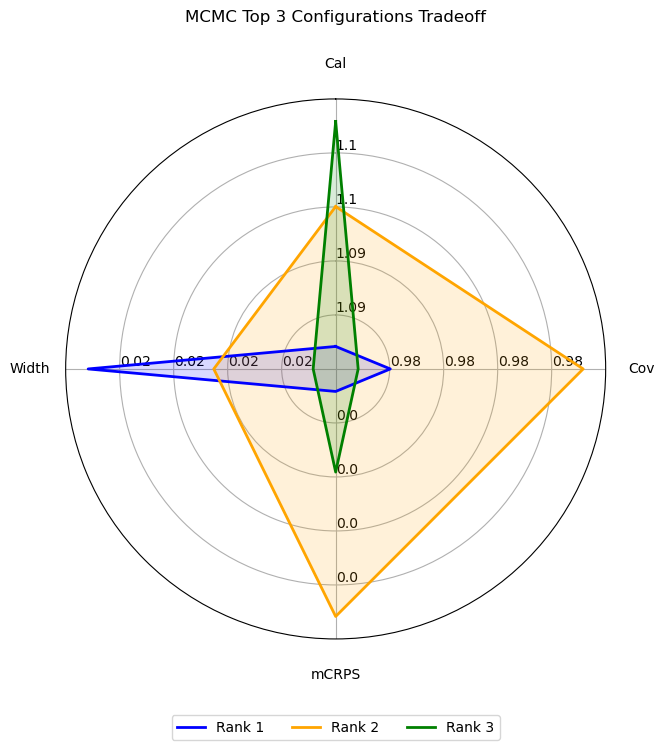

In [53]:
# 3. Radar Chart Projection
metrics = list(metrics_data.keys())
models = list(metrics_data[metrics[0]].keys())

data_matrix = {model: [np.mean(metrics_data[metric][model]) for metric in metrics] for model in models}

ranges = []
for i, metric in enumerate(metrics):
    vals = [data_matrix[m][i] for m in models]
    vmin, vmax = min(vals), max(vals)
    if vmin == vmax:
        ranges.append((vmin - 0.1, vmax + 0.1))
    else:
        padding = (vmax - vmin) * 0.1
        ranges.append((vmin - padding, vmax + padding))

fig1 = plt.figure(figsize=(6, 6))
radar = ComplexRadar(fig1, metrics, ranges)

colors = ['blue', 'orange', 'green']

for i, model in enumerate(models):
    radar.plot(data_matrix[model], label=model, color=colors[i], linewidth=2)
    radar.fill(data_matrix[model], facecolor=colors[i], alpha=0.15)

radar.ax.set_title("MCMC Top 3 Configurations Tradeoff", pad=25)
radar.use_legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=len(models))
plt.show()

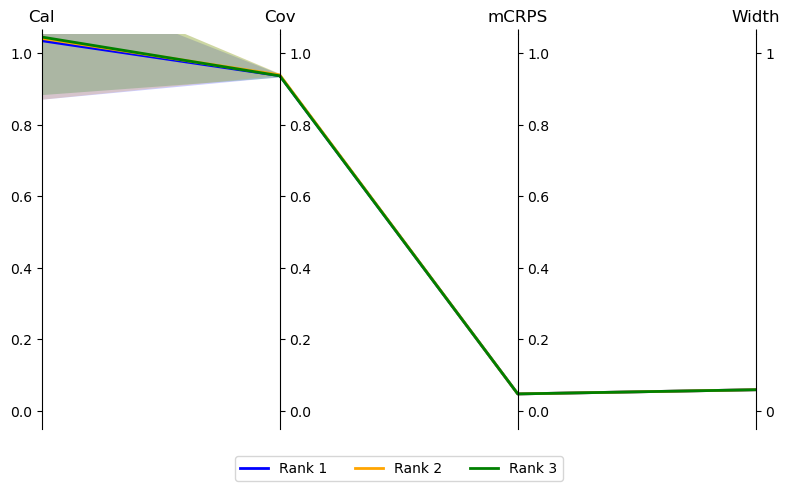

In [54]:
# 4. Parallel Coordinates Projection
bounds = {
    "Cal": [0, 1],
    "Cov": [0, 1],
    "mCRPS": [0, 1],
    "Width": [0, 1]
}

plot_parallel_coordinates_ci(metrics_data, bounds=bounds, colors=colors)

In [2]:
dic = {
    "Cal": {
        "MCMC": [0.1, 0.2, 0.15, 0.1],
        "VI": [0.3, 0.4, 0.35, 0.3],
        "SSVS": [0.5, 0.6, 0.55, 0.5],
        "QR":  [0.8, 0.9, 0.85, 0.8],
    },
    "Cov": {
        "MCMC": [0.9, 0.95, 0.92, 0.91],
        "VI": [0.8, 0.85, 0.82, 0.81],
        "SSVS": [0.7, 0.75, 0.72, 0.71],
        "QR":  [0.6, 0.65, 0.62, 0.61],
    },
    "mCPRS": {
        "MCMC": [0.05, 0.06, 0.055, 0.05],
        "VI": [0.15, 0.16, 0.155, 0.15],
        "SSVS": [0.25, 0.26, 0.255, 0.25],
        "QR":  [0.35, 0.36, 0.355, 0.35],
    },
    "Width": {
        "MCMC": [5, 10, 6, 6],
        "VI": [4, 5, 6, 7],
        "SSVS": [3, 8, 9, 10],
        "QR":  [12, 15, 5, 3],
    }
}


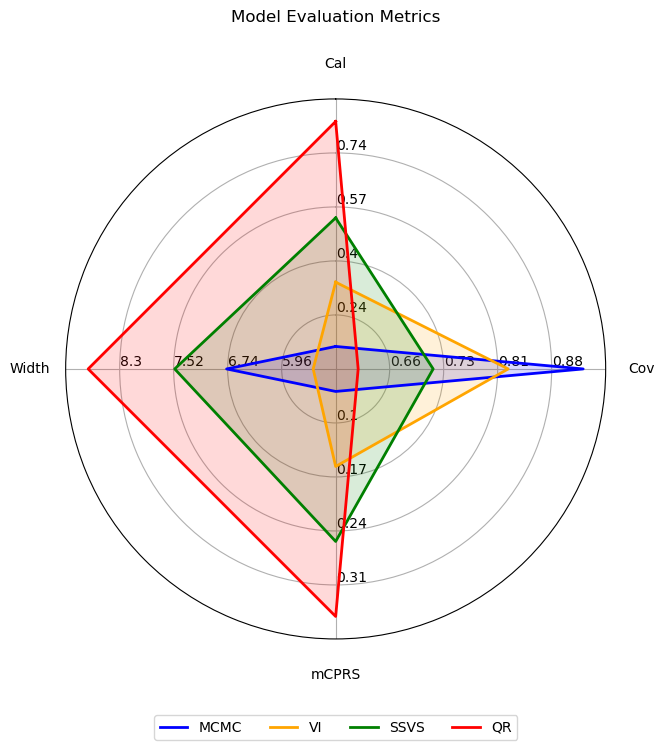

In [3]:
metrics = list(dic.keys())
models = list(dic[metrics[0]].keys())

data_matrix = {model: [np.mean(dic[metric][model]) for metric in metrics] for model in models}

ranges = []
for i, metric in enumerate(metrics):
    vals = [data_matrix[m][i] for m in models]
    vmin, vmax = min(vals), max(vals)
    if vmin == vmax:
        ranges.append((vmin - 0.1, vmax + 0.1))
    else:
        padding = (vmax - vmin) * 0.1
        ranges.append((vmin - padding, vmax + padding))

fig = plt.figure(figsize=(6, 6))
radar = ComplexRadar(fig, metrics, ranges)

colors = ['blue', 'orange', 'green', 'red']

for i, model in enumerate(models):
    radar.plot(data_matrix[model], label=model, color=colors[i], linewidth=2)
    radar.fill(data_matrix[model], facecolor=colors[i], alpha=0.15)

radar.ax.set_title("Model Evaluation Metrics", pad=25)
radar.use_legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=len(models))
plt.show()

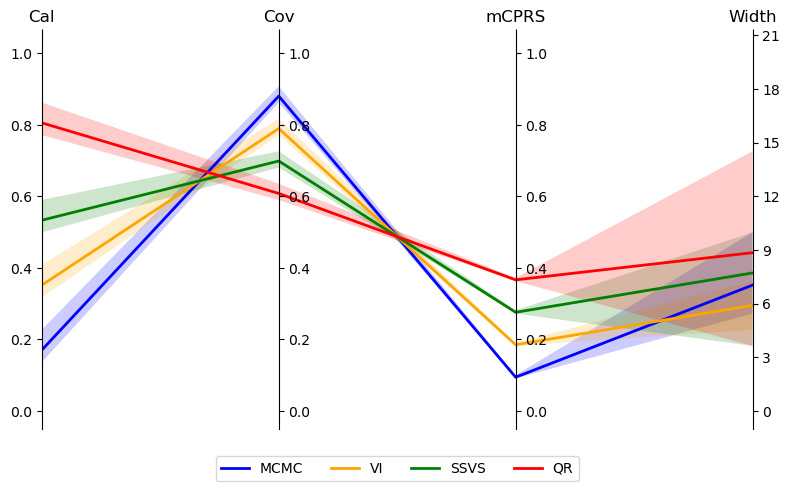

In [4]:
bounds={"Cal":[0,1],
        "Cov":[0,1],
        "mCPRS":[0,1],
        "Width":[0,20]
}
plot_parallel_coordinates_ci(dic, bounds)